/usr/local/lib/python3.11/dist-packages/sklearn/neighbors/_lof.py:322: UserWarning: Duplicate values are leading to incorrect results. Increase the number of neighbors for more accurate results.
  warnings.warn(


Anomalies detected: 272
Random Forest Accuracy: 0.5489795918367347
Gradient Boosting Accuracy: 0.573469387755102
     Feature  Importance
2  Feature 2    0.429699
1  Feature 1    0.290103
0  Feature 0    0.280198


<ipython-input-9-940d1eec0f39>:68: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance, palette='viridis')


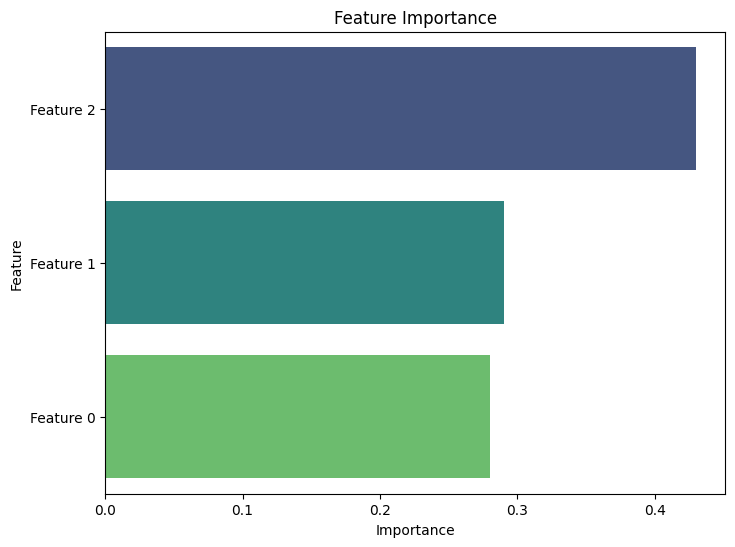

Best model saved successfully!
Predicted outcome: 4
Batch Predictions: [4 4 3]


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
2718/2718 - 13s - 5ms/step - loss: 0.0212
Epoch 2/10
2718/2718 - 11s - 4ms/step - loss: 0.0201
Epoch 3/10
2718/2718 - 10s - 4ms/step - loss: 0.0199
Epoch 4/10
2718/2718 - 9s - 3ms/step - loss: 0.0199
Epoch 5/10
2718/2718 - 8s - 3ms/step - loss: 0.0198
Epoch 6/10
2718/2718 - 9s - 3ms/step - loss: 0.0198
Epoch 7/10
2718/2718 - 9s - 3ms/step - loss: 0.0197
Epoch 8/10
2718/2718 - 8s - 3ms/step - loss: 0.0197
Epoch 9/10
2718/2718 - 10s - 4ms/step - loss: 0.0197
Epoch 10/10
2718/2718 - 9s - 3ms/step - loss: 0.0197
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 327ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
Future Earthquake Predictions (ARIMA): [4.36578161 4.17363161 4.09635156 4.06459356 4.09874607]
Future Earthquake Predictions (LSTM): [[3.768857 ]
 [3.6734574]
 [3.6634278]
 [3.6623847]
 [3.6622763]]


In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import pickle
from sklearn import metrics
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
import shap
from sklearn.neighbors import LocalOutlierFactor
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.arima.model import ARIMA
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.preprocessing import MinMaxScaler

# Load the dataset
data = pd.read_csv("/content/dataset.csv")

# Convert to numpy array
data = np.array(data)
X = data[:, 0:-1]
y = data[:, -1]
y = y.astype('int')
X = X.astype('int')

# Detect anomalies
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.1)
anomalies = lof.fit_predict(X)
print(f"Anomalies detected: {sum(anomalies == -1)}")

# Remove anomalies
X = X[anomalies == 1]
y = y[anomalies == 1]

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

# Train models
rfc = RandomForestClassifier()
gbc = GradientBoostingClassifier()
rfc.fit(X_train, y_train)
gbc.fit(X_train, y_train)

# Predictions
y_pred_rfc = rfc.predict(X_test)
y_pred_gbc = gbc.predict(X_test)

# Accuracy
accuracy_rfc = metrics.accuracy_score(y_test, y_pred_rfc)
accuracy_gbc = metrics.accuracy_score(y_test, y_pred_gbc)
print(f"Random Forest Accuracy: {accuracy_rfc}")
print(f"Gradient Boosting Accuracy: {accuracy_gbc}")

# SHAP values
'''explainer = shap.Explainer(rfc, X_train)
shap_values = explainer(X_test)
shap.summary_plot(shap_values, X_test)'''

# Feature importance
feature_importance = pd.DataFrame({
    'Feature': [f'Feature {i}' for i in range(X.shape[1])],
    'Importance': rfc.feature_importances_
}).sort_values(by='Importance', ascending=False)
print(feature_importance)

# Plot feature importance
plt.figure(figsize=(8, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance, palette='viridis')
plt.title('Feature Importance')
plt.show()

# Save the best model
best_model = rfc if accuracy_rfc > accuracy_gbc else gbc
with open('best_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)
    print("Best model saved successfully!")

# Function to predict new data
def predict_new_data(new_data):
    with open('best_model.pkl', 'rb') as f:
        model = pickle.load(f)
        # Adjust the number of features to 3
        new_data = np.array(new_data[:3]).reshape(1, -1) # Only take first 3 elements of new_data
        prediction = model.predict(new_data)
        return f"Predicted outcome: {prediction[0]}"

new_sample = [50, 20, 10, 5]  # Adjust based on actual features
print(predict_new_data(new_sample))

# Function for batch predictions
def batch_predict(data_batch):
    with open('best_model.pkl', 'rb') as f:
        model = pickle.load(f)
        data_batch = np.array(data_batch)
        # Adjust the number of features to 3 for each sample in the batch
        data_batch = data_batch[:, :3]  # Select the first 3 columns (features)
        predictions = model.predict(data_batch)
        return predictions

batch_samples = [[50, 20, 10, 5], [30, 15, 8, 3], [60, 25, 12, 7]]
print("Batch Predictions:", batch_predict(batch_samples))

# Function for ARIMA forecasting
def forecast_earthquake_arima(time_series, steps=10):
    model = ARIMA(time_series, order=(5, 1, 0))
    model_fit = model.fit()
    forecast = model_fit.forecast(steps=steps)
    return forecast

# Function for LSTM forecasting
def forecast_earthquake_lstm(time_series, steps=10):
    scaler = MinMaxScaler(feature_range=(0, 1))
    time_series_scaled = scaler.fit_transform(np.array(time_series).reshape(-1, 1))

    # Prepare the training data
    X_train, y_train = [], []
    for i in range(len(time_series_scaled) - 1):
        X_train.append(time_series_scaled[i])
        y_train.append(time_series_scaled[i + 1])

    X_train, y_train = np.array(X_train), np.array(y_train)
    X_train = X_train.reshape((X_train.shape[0], 1, X_train.shape[1]))

    # Build the LSTM model
    model = Sequential([
        LSTM(50, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])),
        LSTM(50, return_sequences=False),
        Dense(25),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mean_squared_error')
    model.fit(X_train, y_train, epochs=10, batch_size=1, verbose=2)

    # Forecasting
    last_known = np.array(time_series_scaled[-1]).reshape(1, 1, 1)
    predictions = []
    for _ in range(steps):
        pred = model.predict(last_known)
        predictions.append(pred[0][0])
        last_known = np.array(pred).reshape(1, 1, 1)

    return scaler.inverse_transform(np.array(predictions).reshape(-1, 1))

# Assuming the last column has time-based magnitude values
time_series = data[:, -1]  # Adjust based on your dataset
future_arima = forecast_earthquake_arima(time_series, steps=5)
future_lstm = forecast_earthquake_lstm(time_series, steps=5)

print("Future Earthquake Predictions (ARIMA):", future_arima)
print("Future Earthquake Predictions (LSTM):", future_lstm)